In [ ]:
# Configuration & N-Gram Preview...

"""
#README

RESEARCH OBJECTIVES & SCOPE
--------------------------------------------------------------------------------
The main purpose of this research is to build a Classical SMT model based on the
literature available that inspired the MOSES statistical tool. The program compiles
a robust standalone model with striking similarities to earlier SMT models while
keeping an original flair without relying on complex filing structures. This code
is supposed to run entirely on its own provided you input appropriately structured
JSON documents. The output of the classical SMT model is evaluated in tandem with
Facebook's NLLB-200 model. While the goal is not to prove that this model *beats*
the NLLB-200, it is important to note the strengths and weaknesses of both models.
Compared to MOSES, this model operates on a more heuristic approach, ensuring that
it does not need Expectation-Maximization (EM) to conclude the findings. This does
make the program more appealing to run on a local computer with no setup reqiured.

ACKNOWLEDGMENTS
--------------------------------------------------------------------------------
The implementation of this work draws on substantial inspiration from the stylistic
prose transfer frameworks established by Keith Carlson, Allen Riddell, and David Rockmore
in "Evaluating prose style transfer with the Bible" (2018). This paper details the vast
utility of using a Bible corpus for machine translation and prose style transfer with 
statistical toolkits like MOSES. Python Community Libraries played an important role in
allowing and enabling me to build this project. Some of the big ones I used include:
matplotlib, nltk, pandas, numpy, sacrebleu, and torch (PyTorch). The Hugging Face Transformers
for state-of-the-art neural model integration for NLLB-200 was also vital for the scope of this project.
Utilized development assistance for script structuring, syntactic review, and debugging.
"""

# Global Imports
import json
import math
import os
import re
import matplotlib.pyplot
from collections import defaultdict, Counter
from IPython.display import clear_output, display, HTML
from nltk.util import ngrams
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu, corpus_bleu
import pandas
import numpy
import random
import sacrebleu
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

#Input your directory where you leave the Corpus file. This file should be saved next to the Corpus folder. Do not include Corpus in the directory.
directory = "/Users/USER/Documents/Code/"
bibles = {
    "EN BBE": "en_bbe.json", "EN KJV": "en_kjv.json",
    "PT AA": "pt_aa.json", "PT ACF": "pt_acf.json", "PT NVI": "pt_nvi.json"
}

# Unifies the list of Bible books across one lexical vernacular. Different languages and versions often have unique names
canonized_books = [
    "Genesis", "Exodus", "Leviticus", "Numbers", "Deuteronomy", "Joshua", "Judges", "Ruth", "1 Samuel", "2 Samuel",
    "1 Kings", "2 Kings", "1 Chronicles", "2 Chronicles", "Ezra", "Nehemiah", "Esther", "Job", "Psalms", "Proverbs",
    "Ecclesiastes", "Song of Solomon", "Isaiah", "Jeremiah", "Lamentations", "Ezekiel", "Daniel", "Hosea", "Joel",
    "Amos", "Obadiah", "Jonah", "Micah", "Nahum", "Habakkuk", "Zephaniah", "Haggai", "Zechariah", "Malachi", "Matthew",
    "Mark", "Luke", "John", "Acts", "Romans", "1 Corinthians", "2 Corinthians", "Galatians", "Ephesians", "Philippians",
    "Colossians", "1 Thessalonians", "2 Thessalonians", "1 Timothy", "2 Timothy", "Titus", "Philemon", "Hebrews", "James",
    "1 Peter", "2 Peter", "1 John", "2 John", "3 John", "Jude", "Revelation",
]

# Pre-operations on text data. Includes text-processing, cleaning, tokenization, and a visual n-gram model.
regex_scribe = re.compile(r'\w+')
clean_tokenize = lambda text: regex_scribe.findall(str(text).lower()) if pandas.notna(text) else []
ngramize = lambda tokens, n: [" ".join(g) for g in ngrams(tokens, n)]

# Starts to compile the Corpus Bibles into alignment by book, chapter, and verse
canonized_bibles = []
for bible_name, file_name in bibles.items():
    pathway = os.path.join(directory, "Corpus", file_name)
    if not os.path.exists(pathway): raise FileNotFoundError(f"Missing {pathway}")
    
    with open(pathway, "r", encoding="utf-8-sig") as opened_file:
        bible = json.load(opened_file)
    
    verses = []
    for index, book in enumerate(bible):
        title = canonized_books[index] if index < len(canonized_books) else book.get("name")
        for chapter, chapters in enumerate(book.get("chapters", []), 1):
            for verse, text in enumerate(chapters, 1):
                verses.append({"Verse_ID": f"{title} {chapter}:{verse}", bible_name: str(text).strip()})
    
    if verses: canonized_bibles.append(pandas.DataFrame(verses).set_index("Verse_ID"))

# Commits to alignment using the outer join method
bible_corpus = canonized_bibles[0].join(canonized_bibles[1:], how="outer").reset_index()

# Designates the Bible in Basic English (BBE) the source, so our model can translate Basic English
# Designates King James Version (KJV) a target for archaic english prose-style transfer
# Designates all Portuguese (PT) Bibles targets for Statistical Machine Translation (SMT)
source, targets = "EN BBE", ["EN KJV", "PT AA", "PT ACF", "PT NVI"]

# Converts all text data to string and strips away unnecessary spaces
verse_sanctuary = lambda x: pandas.notna(x) and str(x).strip().lower() not in ("", "nan")

# Ensures that none of the verses are missing in the dataset
alignment = bible_corpus[source].apply(verse_sanctuary)
for target_verse in targets: alignment &= bible_corpus[target_verse].apply(verse_sanctuary)

# Isolates missing verses and exports them for evaluation
missing_verses = bible_corpus[~alignment]
biblical_output = os.path.join(directory, "Output_Directory")
os.makedirs(biblical_output, exist_ok=True)
missing_verses.to_csv(os.path.join(biblical_output, "missing_verses.csv"), index=False, encoding="utf-8")

# Prepare completely aligned verses for modeling
aligned_corpus = bible_corpus[alignment].reset_index(drop=True)

# Aligned Data Preview
print(f"\n Data Preview: Quasi-Random Sample (Missing Verses Exported: {len(missing_verses):,})")
display(aligned_corpus.sample(n=min(10, len(aligned_corpus)), random_state=None))
print(f"Total verses index: {len(aligned_corpus):,}")

# N-Gram Preview
print("\n Stratified Random N-Gram Preview")
sample = aligned_corpus.sample(n=min(2, len(aligned_corpus)))
data_preview = []

for target_verse in [source] + targets:
    if target_verse not in aligned_corpus.columns: continue
    for _, item in sample.iterrows():
        if not verse_sanctuary(item.get(target_verse, "")): continue
        tokens = clean_tokenize(item[target_verse])
        data_preview.append({
            "Version & Verse_ID": f"{target_verse} - {item['Verse_ID']}",
            "Unigram Tokens": tokens,
            "Bigram Tokens": ngramize(tokens, 2),
            "Trigram Tokens": ngramize(tokens, 3)
        })

display(pandas.DataFrame(data_preview))

count = [len(clean_tokenize(passage)) for passage in aligned_corpus[source]]
print(f"Total Unigrams: {sum(count):,} | Total Bigrams: {sum(max(0, length - 1) for length in count):,} | Total Trigrams: {sum(max(0, length - 2) for length in count):,}")

/Users/feldsottbenjamin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



 Data Preview: Quasi-Random Sample (Missing Verses Exported: 13)


,Verse_ID,EN BBE,EN KJV,PT AA,PT ACF,PT NVI
511,Genesis 20:16,"And he said to Sarah, See, I have given to you...","And unto Sarah he said, Behold, I have given t...",E a Sara disse: Eis que tenho dado a teu irmão...,E a Sara disse: Vês que tenho dado ao teu irmã...,"A Sara ele disse: ""Estou dando a seu irmão mil..."
23289,Matthew 6:8,So be not like them; because your Father has k...,Be not ye therefore like unto them: for your F...,"Não vos assemelheis, pois, a eles; porque voss...","Não vos assemelheis, pois, a eles; porque voss...","Não sejam iguais a eles, porque o seu Pai sabe..."
7525,1 Samuel 14:17,Then Saul said to the people who were with him...,Then said Saul unto the people that {were} wit...,Disse então Saul ao povo que estava com ele: O...,Disse então Saul ao povo que estava com ele: O...,"Então Saul disse aos seus soldados: ""Contem os..."
11666,2 Chronicles 23:10,"And he put all the people in position, every m...","And he set all the people, every man having hi...","E dispôs todo o povo, cada um com as suas arma...","E dispôs todo o povo, a cada um com as suas ar...","Posicionou todos os homens, todos de arma na m..."
19761,Jeremiah 32:30,For the children of Israel and the children of...,For the children of Israel and the children of...,Pois os filhos de Israel e os filhos de Judá t...,Porque os filhos de Israel e os filhos de Judá...,"""Desde a sua juventude o povo de Israel e de J..."
13804,Job 38:11,"And said, So far you may come, and no farther;...","And said, Hitherto shalt thou come, but no fur...","e lhe disse: Até aqui virás, porém não mais ad...","E disse: Até aqui virás, e não mais adiante, e...","quando eu lhe disse: Até aqui você pode vir, a..."
27781,Acts 24:20,Or let these men here present say what wrongdo...,"Or else let these same {here} say, if they hav...","ou estes mesmos digam que iniqüidade acharam, ...","Ou digam estes mesmos, se acharam em mim algum...",Ou os que aqui se acham deveriam declarar que ...
3613,Numbers 1:9,"From Zebulun, Eliab, the son of Helon;",Of Zebulun; Eliab the son of Helon.,"de Zebulom, Eliabe, filho de Helom;","De Zebulom, Eliabe, filho de Helom;","de Zebulom, Eliabe, filho de Helom;"
28286,Romans 14:14,"I am conscious of this, and am certain in the ...","I know, and am persuaded by the Lord Jesus, th...","Eu sei, e estou certo no Senhor Jesus, que nad...","Eu sei, e estou certo no Senhor Jesus, que nen...","Como alguém que está no Senhor Jesus, tenho pl..."
8697,2 Samuel 24:5,"And they went over Jordan, and starting from A...","And they passed over Jordan, and pitched in Ar...","Tendo eles passado o Jordão, acamparam-se em A...","E passaram o Jordão; e acamparam-se em Aroer, ...","E atravessando o Jordão, começaram em Aroer, a..."


Total verses index: 31,095

 Stratified Random N-Gram Preview


,Version & Verse_ID,Unigram Tokens,Bigram Tokens,Trigram Tokens
0,EN BBE - Numbers 3:49,"[so, moses, took, the, money, the, price, of, ...","[so moses, moses took, took the, the money, mo...","[so moses took, moses took the, took the money..."
1,EN BBE - Revelation 21:23,"[and, the, town, has, no, need, of, the, sun, ...","[and the, the town, town has, has no, no need,...","[and the town, the town has, town has no, has ..."
2,EN KJV - Numbers 3:49,"[and, moses, took, the, redemption, money, of,...","[and moses, moses took, took the, the redempti...","[and moses took, moses took the, took the rede..."
3,EN KJV - Revelation 21:23,"[and, the, city, had, no, need, of, the, sun, ...","[and the, the city, city had, had no, no need,...","[and the city, the city had, city had no, had ..."
4,PT AA - Numbers 3:49,"[então, moisés, recebeu, o, dinheiro, da, rede...","[então moisés, moisés recebeu, recebeu o, o di...","[então moisés recebeu, moisés recebeu o, receb..."
5,PT AA - Revelation 21:23,"[a, cidade, não, necessita, nem, do, sol, nem,...","[a cidade, cidade não, não necessita, necessit...","[a cidade não, cidade não necessita, não neces..."
6,PT ACF - Numbers 3:49,"[então, moisés, tomou, o, dinheiro, do, resgat...","[então moisés, moisés tomou, tomou o, o dinhei...","[então moisés tomou, moisés tomou o, tomou o d..."
7,PT ACF - Revelation 21:23,"[e, a, cidade, não, necessita, de, sol, nem, d...","[e a, a cidade, cidade não, não necessita, nec...","[e a cidade, a cidade não, cidade não necessit..."
8,PT NVI - Numbers 3:49,"[assim, moisés, recolheu, a, prata, para, o, r...","[assim moisés, moisés recolheu, recolheu a, a ...","[assim moisés recolheu, moisés recolheu a, rec..."
9,PT NVI - Revelation 21:23,"[a, cidade, não, precisa, de, sol, nem, de, lu...","[a cidade, cidade não, não precisa, precisa de...","[a cidade não, cidade não precisa, não precisa..."


Total Unigrams: 847,294 | Total Bigrams: 816,234 | Total Trigrams: 785,174


In [ ]:
# Defining the All_Portuguese Training Corpus...


"""
Defines core functions necessary to produce a specific All_Portuguese target prose style
that may utilize the entire 'PT' corpus. Formats the raw text into tokenized source-target
mappings to contribute the data structures required for training and cross-validation.
"""


source_bible = "EN BBE"
portuguese_bibles = ["PT AA", "PT ACF", "PT NVI"]
target_bibles = ["EN KJV", "PT AA", "PT ACF", "PT NVI", "All_Portuguese"]

def extract_scripture(target):    
    # Build the sanctuary mask using verse_sanctuary function
    sanctuary = aligned_corpus[source_bible].apply(verse_sanctuary)
    if target == "All_Portuguese":
        for model in portuguese_bibles:
            sanctuary &= aligned_corpus[model].apply(verse_sanctuary)
    else:
        sanctuary &= aligned_corpus[target].apply(verse_sanctuary)

    return aligned_corpus[sanctuary]

def witness(corpus_scripture, target):
    
    get_witness = []    
    active_targets = portuguese_bibles if target == "All_Portuguese" else [target]
    
    for verse in corpus_scripture.to_dict('records'):
        source_verse = clean_tokenize(verse[source_bible])
        
        for version in active_targets: 
            target_verse = clean_tokenize(verse[version])
            if source_verse and target_verse:
                get_witness.append((source_verse, target_verse))
                
    return get_witness

all_portuguese_corpus = witness(extract_scripture("All_Portuguese"), "All_Portuguese")

# Preview of All_Portuguese
print("Source:")
print(f"\t{' '.join(all_portuguese_corpus[0][0]).capitalize()}.")
print("All Portuguese:")
for x in [all_portuguese_corpus[i][1] for i in range(3)]:
    print(f"\t{' '.join(x).capitalize()}.")

Source:
	At the first god made the heaven and the earth.
All Portuguese:
	No princípio criou deus os céus e a terra.
	No princípio criou deus o céu e a terra.
	No princípio deus criou os céus e a terra.


,1-gram,2-gram,3-gram,4-gram,Target Version,Best N-gram
0,468.83,142.26,141.26,151.89,EN KJV,3
1,806.95,274.60,294.45,312.84,PT AA,2
2,739.08,249.01,267.27,284.72,PT ACF,2
3,917.16,296.61,309.93,326.45,PT NVI,2
4,879.86,273.38,287.04,311.74,All_Portuguese,2


,1-gram,2-gram,3-gram,4-gram,Target Version,Best N-gram
0,444.23,85.58,65.98,81.35,EN KJV,3
1,780.48,139.95,135.77,179.53,PT AA,3
2,711.02,129.55,124.21,164.87,PT ACF,3
3,880.15,143.32,133.89,172.48,PT NVI,3
4,834.91,144.26,130.38,182.26,All_Portuguese,3


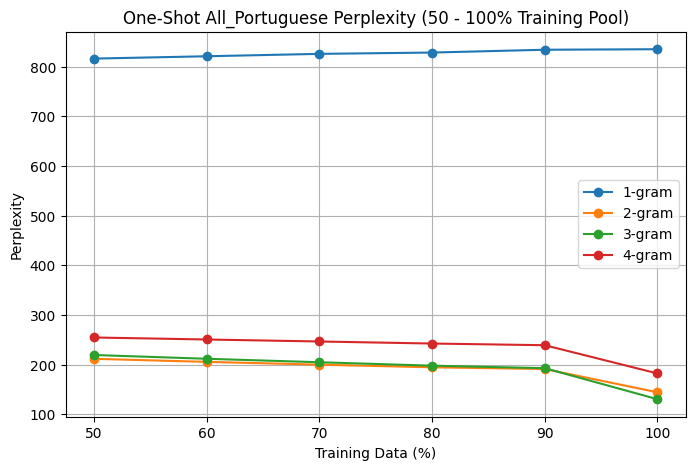

In [ ]:
# Evaluating the Language Model (LM) Perplexity

"""
Explores the ideal N-Gram for the Language Model (LM) by iterating through different N-Gram models
with K-Fold Cross Validation set at K=10. Also notably evaluates how the dataset deals with a 90:10
training:testing split versus 100% trained-and-tested on the same data. Concludes that the bigram model
is the best but it is worth noting that when the model is familiar with the entire dataset (100% context knowledge)
it does better with the trigram model on data that it is familiar with.
"""



print("Evaluating the Language Model (LM)...", flush=True)

test_scripture = []
full_scripture = []

def scriptural_perplexity(training_corpus, testing_corpus):
    frequencies = [defaultdict(lambda: defaultdict(int)) for _ in range(5)]
    tallies = [defaultdict(int) for _ in range(5)]
    lexicon = set()
    
    for _, tokens in training_corpus:
        lexicon.update(tokens)
        crucible_size = 3
        crucible_tokens = ["<s>"] * crucible_size + tokens + ["</s>"]
        for crucible_index in range(len(crucible_tokens)):
            crucible_target = crucible_tokens[crucible_index]
            frequencies[1][()][crucible_target] += 1
            tallies[1][()] += 1
            if crucible_index >= 1:
                crucible_tuple_2g = (crucible_tokens[crucible_index-1],)
                frequencies[2][crucible_tuple_2g][crucible_target] += 1
                tallies[2][crucible_tuple_2g] += 1
            if crucible_index >= 2:
                crucible_tuple_3g = (crucible_tokens[crucible_index-2], crucible_tokens[crucible_index-1])
                frequencies[3][crucible_tuple_3g][crucible_target] += 1
                tallies[3][crucible_tuple_3g] += 1
            if crucible_index >= 3:
                crucible_tuple_4g = (crucible_tokens[crucible_index-3], crucible_tokens[crucible_index-2], crucible_tokens[crucible_index-1])
                frequencies[4][crucible_tuple_4g][crucible_target] += 1
                tallies[4][crucible_tuple_4g] += 1

    vocabulary_size = len(lexicon)
    perplexity_results = {}
    
    penalty = 0.01 * vocabulary_size
    prob = 0.01 / (1.0 + penalty)
    
    for ngram_decree in range(1, 5):
        log_score = 0.0
        token_count = 0
        crusade_size = max(0, ngram_decree - 1)
        
        for _, tokens in testing_corpus:
            crusade_tokens = ["<s>"] * crusade_size + tokens + ["</s>"]
            
            for crusade_index in range(crusade_size, len(crusade_tokens)):
                current_token = crusade_tokens[crusade_index]  
                if ngram_decree == 1:
                    crusade_context = ()
                elif ngram_decree == 2:
                    crusade_context = (crusade_tokens[crusade_index-1],)
                elif ngram_decree == 3:
                    crusade_context = (crusade_tokens[crusade_index-2], crusade_tokens[crusade_index-1])
                else:
                    crusade_context = (crusade_tokens[crusade_index-3], crusade_tokens[crusade_index-2], crusade_tokens[crusade_index-1])
                
                smoothed_probability = prob
                for backoff_depth in range(ngram_decree, 0, -1):
                    if backoff_depth == 1:
                        backoff_context = ()
                    elif backoff_depth == 2:
                        backoff_context = (crusade_context[-1],)
                    elif backoff_depth == 3:
                        backoff_context = (crusade_context[-2], crusade_context[-1])
                    else:
                        backoff_context = crusade_context
                        
                    freq_dict = frequencies[backoff_depth].get(backoff_context)
                    if freq_dict and current_token in freq_dict:
                        divine_numerator = freq_dict[current_token] + 0.01
                        denominator = tallies[backoff_depth][backoff_context] + penalty
                        smoothed_probability = divine_numerator / denominator
                        break
                        
                log_score += math.log(max(smoothed_probability, 1e-10))
                token_count += 1
                
        perplexity_results[f"{ngram_decree}-gram"] = math.exp(-log_score / token_count) if token_count > 0 else float('inf')
        
    return perplexity_results

for version in target_bibles:
    codex = extract_scripture(version)
    if codex.empty: continue

    full_corpus = list(witness(codex, version))

    # 10-Fold 90:10 Cross-Validation
    fold_count = 10
    fold_size = len(full_corpus) // fold_count
    validation_partitions = [full_corpus[tally * fold_size : (tally + 1) * fold_size] for tally in range(fold_count)]
    accumulated_scores = {f"{ngram_decree}-gram": [] for ngram_decree in range(1, 5)}
    
    for fold_index in range(fold_count):
        training_corpus = []
        for j, fold_data in enumerate(validation_partitions):
            if j != fold_index:
                training_corpus.extend(fold_data)
        
        testing_corpus = validation_partitions[fold_index]
        
        fold_results = scriptural_perplexity(training_corpus, testing_corpus)
        for ngram_decree in range(1, 5):
            accumulated_scores[f"{ngram_decree}-gram"].append(fold_results[f"{ngram_decree}-gram"])
    
    mean_metrics = {column_key: round(sum(values) / fold_count, 2) for column_key, values in accumulated_scores.items()}
    mean_metrics.update({
        "Target Version": version, 
        "Best N-gram": min(range(1, 5), key=lambda ngram_decree: mean_metrics[f"{ngram_decree}-gram"])
    })
    test_scripture.append(mean_metrics)

    # 2. 100% Training Evaluation
    full_training_metrics = {column_key: round(value, 2) for column_key, value in scriptural_perplexity(full_corpus, full_corpus).items()}
    full_training_metrics.update({
        "Target Version": version, 
        "Best N-gram": min(range(1, 5), key=lambda ngram_decree: full_training_metrics[f"{ngram_decree}-gram"])
    })
    full_scripture.append(full_training_metrics)
    print(f"  🎆 Completed evaluation for {version}... 🎆", flush=True)

clear_output(wait=True)

# Captions attached directly to the dataframes to ensure they render perfectly
display(pandas.DataFrame(test_scripture).style.set_caption("10-Fold 90:10 Ratio for Training:Testing").format(precision=2))
display(pandas.DataFrame(full_scripture).style.set_caption("100% Training Data (Tested on Training)").format(precision=2))

# 3. MatPlotLib's Scaling Graph
divine_test = "All_Portuguese"  # Switch to "EN KJV", "PT AA", "PT ACF", "PT NVI", "All_Portuguese"

target_corpus = extract_scripture(divine_test)
full_graph = list(witness(target_corpus, divine_test))
random.Random(None).shuffle(full_graph)

sample_weights = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
perplexity_scores = {n: [] for n in range(1, 5)}

for endeavor in sample_weights:
    training_mark = int(len(full_graph) * endeavor)
    
    subset_training_corpus = full_graph[:training_mark]
    testing_corpus = full_graph[training_mark:]
    
    if endeavor == 1.0:
        test_corpus = subset_training_corpus
    else:
        test_corpus = testing_corpus
    
    intrepid_results = scriptural_perplexity(subset_training_corpus, test_corpus)
    
    for n in range(1, 5):
        perplexity_scores[n].append(intrepid_results[f"{n}-gram"])

matplotlib.pyplot.figure(figsize=(8, 5))
for n in range(1, 5):
    matplotlib.pyplot.plot(
        [int(f * 100) for f in sample_weights], 
        perplexity_scores[n], 
        marker='o', 
        label=f'{n}-gram'
    )
matplotlib.pyplot.title(f"One-Shot {divine_test} Perplexity (50 - 100% Training Pool)")
matplotlib.pyplot.xlabel("Training Data (%)")
matplotlib.pyplot.ylabel("Perplexity")
matplotlib.pyplot.legend()
matplotlib.pyplot.grid(True)
matplotlib.pyplot.show()

In [ ]:
# Evaluating the Translation Model (TM) with BLEU...


"""
Evaluates the Translation Model using the Dice Coefficient and similar methodology 
to the tests we did on the LM. In this case, it is assumed that the unigram model will prevail
based on the fact that the dataset is quite small and incapable of dealing with complex
linguistic topic matter like idiomatic expressions. Implements 10-fold cross validation and BLEU-2 scores.
"""


smooth_function = SmoothingFunction().method1
scripture_test = []
scripture_full = []

print("Evaluating the Translation Model (TM) with BLEU...", flush=True)

def scriptural_translation(training_corpus, testing_corpus):
    source_tallies = {n: Counter() for n in range(1, 5)}
    target_tallies = {n: Counter() for n in range(1, 5)}
    covenant_frequencies = {n: defaultdict(Counter) for n in range(1, 5)}
    
    for source_tokens, target_tokens in training_corpus:
        for n in range(1, 5):
            source_tally = source_tallies[n]
            target_tally = target_tallies[n]
            covenant_tally = covenant_frequencies[n]
            
            if n == 1:
                scriptural_source = set(source_tokens)
                scriptural_target = set(target_tokens)
            else:
                scriptural_source = set(tuple(source_tokens[holy_index:holy_index+n]) for holy_index in range(len(source_tokens)-n+1))
                scriptural_target = set(tuple(target_tokens[holy_index:holy_index+n]) for holy_index in range(len(target_tokens)-n+1))
            
            source_tally.update(scriptural_source)
            target_tally.update(scriptural_target)
            
            for source_element in scriptural_source:
                covenant_source = covenant_tally[source_element]
                for target_element in scriptural_target: 
                    covenant_source[target_element] += 1
            
    # Top-1 Phrase Lexicon with Dice Coefficient
    divine_lexicon = {n: {} for n in range(1, 5)}
    for n in range(1, 5):
        sacred_lexicon = divine_lexicon[n]
        target_tally = target_tallies[n]
        
        for source_element, target_frequencies in covenant_frequencies[n].items():
            if not target_frequencies:
                continue
                
            source_frequency = source_tallies[n][source_element]  
            sacred_champion = max(
                target_frequencies.items(), 
                key=lambda divine_right: (2.0 * divine_right[1]) / (source_frequency + target_tally[divine_right[0]])
            )[0]
            sacred_lexicon[source_element] = sacred_champion
    
    # Calculate BLEU Scores
    bleu_results = {}
    sacred_references = [[target_tokens] for _, target_tokens in testing_corpus]
    
    for n in range(1, 5):
        sacred_manuscript = []
        sacred_lexicon = divine_lexicon[n]
        
        for source_tokens, target_tokens in testing_corpus:
            if n == 1:
                scriptural_source = source_tokens
            else:
                scriptural_source = [tuple(source_tokens[scriptural_index:scriptural_index+n]) for scriptural_index in range(0, len(source_tokens), n)]
            
            sacred_scribe = []
            for source_fragment in scriptural_source:
                translation = sacred_lexicon.get(source_fragment)
                if translation:
                    if n == 1:
                        sacred_scribe.append(translation)
                    else:
                        sacred_scribe.extend(list(translation))
                        
            sacred_manuscript.append(sacred_scribe)
            
        weights = tuple(1.0/n for _ in range(n)) + (0.0,)*(4-n)
        bleu_results[f"{n}-gram"] = corpus_bleu(sacred_references, sacred_manuscript, weights=weights, smoothing_function=smooth_function) * 100
        
    return bleu_results

# Execution
for target in target_bibles:
    codex = extract_scripture(target)
    if codex.empty: 
        continue
        
    aligned_prose = list(witness(codex, target))
    if not aligned_prose: 
        continue

    # 1. 90:10 10-Fold
    fold_count = 10
    fold_size = len(aligned_prose) // fold_count
    validation_partitions = [aligned_prose[tally * fold_size : (tally + 1) * fold_size] for tally in range(fold_count)]
    accumulated_scores = {f"{ngram_decree}-gram": [] for ngram_decree in range(1, 5)}
    
    for fold_index in range(fold_count):
        training_corpus = []
        for partition_index, fold_data in enumerate(validation_partitions):
            if partition_index != fold_index:
                training_corpus.extend(fold_data)
                
        testing_corpus = validation_partitions[fold_index]
        fold_results = scriptural_translation(training_corpus, testing_corpus)
        for ngram_decree in range(1, 5):
            accumulated_scores[f"{ngram_decree}-gram"].append(fold_results[f"{ngram_decree}-gram"])
            
    mean_metrics = {sacred_key: round(sum(sacred_values) / fold_count, 2) for sacred_key, sacred_values in accumulated_scores.items()}
    mean_metrics.update({
        "Target Version": target, 
        "Optimal N-Gram": max(range(1, 5), key=lambda ngram_decree: mean_metrics[f"{ngram_decree}-gram"])
    })
    scripture_test.append(mean_metrics)

    # 2. 100% Training
    training_metrics = scriptural_translation(aligned_prose, aligned_prose)
    training_metrics = {sacred_key: round(sacred_value, 2) for sacred_key, sacred_value in training_metrics.items()}
    training_metrics.update({
        "Target Version": target, 
        "Optimal N-Gram": max(range(1, 5), key=lambda ngram_decree: training_metrics[f"{ngram_decree}-gram"])
    })
    scripture_full.append(training_metrics)
    
    print(f"🎆 Completed evaluation for {target}... 🎆", flush=True)

clear_output(wait=True)

display(pandas.DataFrame(scripture_test).style.set_caption("BLEU Score (90:10 10-Fold CV Mean)").format(precision=2))
display(pandas.DataFrame(scripture_full).style.set_caption("BLEU Score (100% Training)").format(precision=2))

,1-gram,2-gram,3-gram,4-gram,Target Version,Optimal N-Gram
0,56.92,35.56,13.03,2.33,EN KJV,1
1,32.21,19.93,7.88,1.98,PT AA,1
2,33.13,20.35,7.97,1.98,PT ACF,1
3,31.04,16.90,6.71,1.85,PT NVI,1
4,31.26,19.06,7.56,1.91,All_Portuguese,1


,1-gram,2-gram,3-gram,4-gram,Target Version,Optimal N-Gram
0,58.96,44.93,29.32,20.51,EN KJV,1
1,33.51,26.70,20.13,16.85,PT AA,1
2,34.75,27.13,20.46,17.11,PT ACF,1
3,32.69,23.73,18.15,15.68,PT NVI,1
4,32.86,24.03,17.01,13.57,All_Portuguese,1


,Target_Version,0:10,1:9,2:8,3:7,4:6,5:5,6:4,7:3,8:2,9:1,10:0,Optimal Ratio,Best BLEU-2
0,EN KJV,20.06,20.48,20.94,22.21,23.62,25.82,28.12,31.01,33.94,36.98,37.75,10:0,37.75
1,PT AA,9.66,9.75,9.93,10.28,10.69,10.99,11.81,12.68,14.43,15.98,13.64,9:1,15.98
2,PT ACF,10.37,10.44,10.56,10.89,11.25,11.73,12.41,13.27,15.03,16.40,15.64,9:1,16.40
3,PT NVI,9.08,9.15,9.33,9.53,9.79,10.13,10.95,11.99,13.01,14.56,12.22,9:1,14.56
4,All_Portuguese,9.61,9.69,9.84,10.00,10.22,10.99,11.67,12.54,14.14,15.95,15.40,9:1,15.95


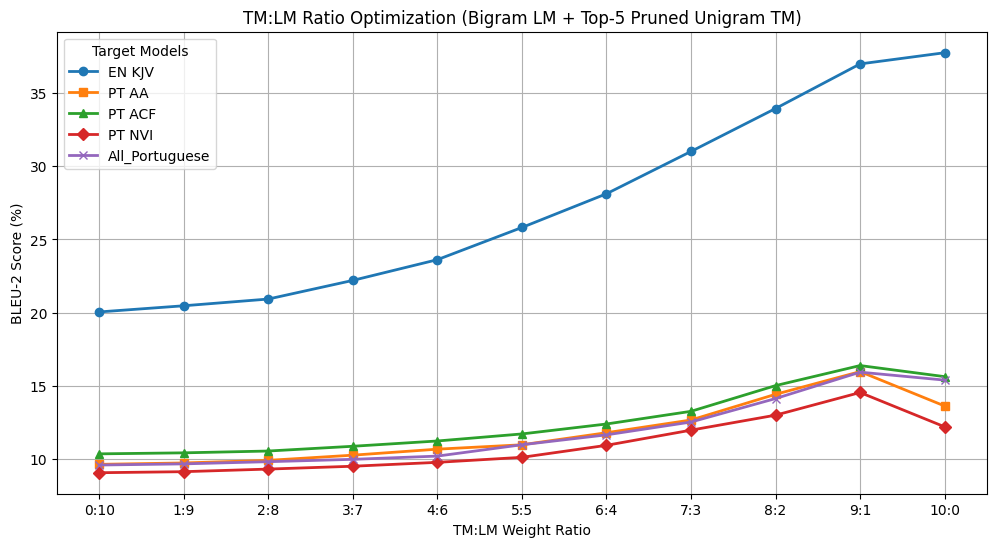

In [ ]:
# Evaluating LM:TM Ratio

"""
In this section we test to find ideal ratios for the TM:LM
We conclude that the optimal ratio is 9:1 given the models enormously prefer
the TM. It is worth noting that EN KJV actually pushes for a full 10:0 ratio,
but this is a very unreliable determination. Again, this section gives insight into
how the model deals with testing data vs 100% trained-on-testing data evaluations.
"""

evaluation_scores = []
model_scores = {}
weight_ratios = [(tenet / 10.0, (10 - tenet) / 10.0) for tenet in range(11)]
ratio_tags = [f"{int(ratio[0]*10)}:{int(ratio[1]*10)}" for ratio in weight_ratios]

print("Evaluating LM:TM Ratio...", flush=True)

for target in target_bibles:
    codex = extract_scripture(target)
    if codex.empty: 
        continue
        
    aligned_prose = witness(codex, target)
    if not aligned_prose: 
        continue

    # 90:10 Split
    part_the_sea = int(len(aligned_prose) * 0.9)
    training_set = aligned_prose[:part_the_sea]
    test_set = aligned_prose[part_the_sea:]

    # Top-5 Pruned Unigram TM (Dice Coefficient)
    source_tally = Counter()
    target_tally = Counter()
    covenant_tally = defaultdict(Counter)

    for source_tokens, target_tokens in training_set:
        source_tally.update(source_tokens)
        target_tally.update(target_tokens)
        source_set = set(source_tokens)
        target_set = set(target_tokens)
        
        for divine_prose in source_set:
            covenant_source = covenant_tally[divine_prose]
            for holy_prose in target_set: 
                covenant_source[holy_prose] += 1

    divine_lexicon = defaultdict(dict)
    
    for source_prose, target_dictionary in covenant_tally.items():
        if not target_dictionary:
            continue
        source_frequency = source_tally[source_prose]
        sacred_score = [
            (holy_prose, math.log(max(2.0 * weight / (source_frequency + target_tally[holy_prose]), 1e-10))) 
            for holy_prose, weight in target_dictionary.items()
        ]
        divine_lexicon[source_prose] = dict(sorted(sacred_score, key=lambda divine_right: divine_right[1], reverse=True)[:5])

    # Bigram LM
    bigrams = defaultdict(lambda: defaultdict(int))
    unigrams = defaultdict(int)
    vocab = set()

    for _, target_tokens in training_set:
        vocab.update(target_tokens)
        stamp = ["<s>"] + target_tokens
        for instance in range(len(stamp) - 1):
            bigrams[stamp[instance]][stamp[instance+1]] += 1
            unigrams[stamp[instance]] += 1

    vocab_size = len(vocab)
    def get_lm_logprob(w1, w2):
        probability = (bigrams[w1][w2] + 0.01) / (unigrams[w1] + 0.01 * vocab_size)
        return math.log(max(probability, 1e-10))

    # Grid Search (0:10 through 10:0)
    biblical_dictionary = {"Target_Version": target}
    bleu_scores = []
    
    references = [[target_tokens] for _, target_tokens in test_set]

    for tm_weight, lm_weight in weight_ratios:
        smt_manuscript = []
        for source_tokens, target_tokens in test_set:
            smt_verse, past_transcendence = [], "<s>"
            for source_word in source_tokens:
                best_target = source_word
                best_score = float('-inf')
                trial = divine_lexicon.get(source_word, {source_word: math.log(1e-10)})
                for initiate, tm_log_probability in trial.items():
                    lm_log_probability = get_lm_logprob(past_transcendence, initiate)
                    score = (tm_weight * tm_log_probability) + (lm_weight * lm_log_probability)
                    if score > best_score:
                        best_score = score
                        best_target = initiate
                        
                smt_verse.append(best_target)
                past_transcendence = best_target
            smt_manuscript.append(smt_verse)

        bleu2 = corpus_bleu(references, smt_manuscript, weights=(0.5, 0.5), smoothing_function=smooth_function) * 100
        ratio_label = f"{int(tm_weight*10)}:{int(lm_weight*10)}"
        biblical_dictionary[ratio_label] = round(bleu2, 2)
        bleu_scores.append(bleu2)

    biblical_index = max(range(len(bleu_scores)), key=lambda i: bleu_scores[i])
    biblical_dictionary["Optimal Ratio"] = ratio_tags[biblical_index]
    biblical_dictionary["Best BLEU-2"] = round(bleu_scores[biblical_index], 2)
    evaluation_scores.append(biblical_dictionary)
    
    model_scores[target] = bleu_scores

    print(f"🎆 Grid search complete for {target} 🎆")
    
clear_output(wait=True)

# 4. Summary Table
evaluation_tablet = pandas.DataFrame(evaluation_scores)
display(
    evaluation_tablet.style
    .set_caption("<b>--- TM:LM Weight Ratio Optimization Table (BLEU-2 Scores) ---</b>")
    .format(precision=2, na_rep="-")
)

# 5. Graphical Summary
matplotlib.pyplot.figure(figsize=(12, 6))

markers = ['o', 's', '^', 'D', 'x'] * (len(model_scores) // 5 + 1)

for (target, scores), marker in zip(model_scores.items(), markers):
    matplotlib.pyplot.plot(ratio_tags, scores, marker=marker, linewidth=2, label=target)

matplotlib.pyplot.title("TM:LM Ratio Optimization (Bigram LM + Top-5 Pruned Unigram TM)")
matplotlib.pyplot.xlabel("TM:LM Weight Ratio")
matplotlib.pyplot.ylabel("BLEU-2 Score (%)")
matplotlib.pyplot.grid(True)
matplotlib.pyplot.legend(title="Target Models")
matplotlib.pyplot.show()

In [ ]:
# Testing the Model...


"""
This section thematically tries to go through the entire corpus and produce statistical results based on BLEU-2 scores.
We implement the optimal ratio of TM:LM and use the methods identified in previous sections of the code. This section provides
substantial context into how the model processes new data and also how it responds to data it has already seen before. It is strongly
recommended to only use this SMT model on language and context that it is familiar with (like similar biblical prose).
"""



testing_limit = None 
target_bibles = ["EN KJV", "PT AA", "PT ACF", "PT NVI"] 

tm_weight = 0.9
lm_weight = 0.1
beam_width = 5
length_penalty = 0.7

fallback_penalty = tm_weight * math.log(1e-10)

def resurrect_prose(tokens):
    sanctified_tokens = [str(token) for token in tokens if token is not None]
    text = re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', " ".join(sanctified_tokens), flags=re.IGNORECASE)
    text = re.sub(r'\s+([.,;:?!])', r'\1', text)
    text = re.sub(r'([.,;:?!])(?=[A-Za-z])', r'\1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if text:
        text = text[0].upper() + text[1:]
        if not text.endswith(('.', '?', '!')): text += "."
    return text

testing_data_storage = {}
training_data_storage = {} 
testing_data_display = []
training_data_display = []
cache = {} 
prophetic_registry = {}

# 90:10 Training:Testing Split
print("Testing the Unseen...", flush=True)

for target in target_bibles:
    print(f"\t{target} Scripture...", flush=True)
    
    codex = extract_scripture(target)
    if codex.empty: 
        continue
        
    holy_prose = codex.dropna(subset=["EN BBE", target]).reset_index(drop=True)
    if holy_prose.empty:
        continue
    
    part_the_sea = int(len(holy_prose) * 0.9)
    training_codex = holy_prose.iloc[:part_the_sea]
    testing_codex = holy_prose.iloc[part_the_sea:]
    
    holy_decode = testing_codex.head(testing_limit) if testing_limit is not None else testing_codex
    
    # Top-5 Pruned Unigram TM (90% Training)
    source_frequency, target_frequency, co_occurences = Counter(), Counter(), defaultdict(Counter)
    for verse_index, verse_data in training_codex.iterrows():
        source_tokens, target_tokens = clean_tokenize(verse_data["EN BBE"]), clean_tokenize(verse_data[target])
        source_frequency.update(source_tokens)
        target_frequency.update(target_tokens)
        for scriptural_word in set(source_tokens):
            divine_covenant = co_occurences[scriptural_word]
            for testament_word in set(target_tokens): 
                divine_covenant[testament_word] += 1
            
    sacred_lexicon = {}
    for scriptural_word, target_dict in co_occurences.items():
        if not target_dict: continue
        divine_frequency = source_frequency[scriptural_word]
        dice_scores = [
            (testament_word, tm_weight * math.log(max(2.0 * weight / (divine_frequency + target_frequency[testament_word]), 1e-10))) 
            for testament_word, weight in target_dict.items()
        ]
        sacred_lexicon[scriptural_word] = dict(sorted(dice_scores, key=lambda pair: pair[1], reverse=True)[:5])

    # Bigram LM (90% Training)
    sacred_bigrams = defaultdict(lambda: defaultdict(int))
    sacred_unigrams = defaultdict(int)
    holy_lexicon = set()
    for verse_index, verse_data in training_codex.iterrows():
        target_tokens = clean_tokenize(verse_data[target])
        holy_lexicon.update(target_tokens)
        divine_stamp = ["<s>"] + target_tokens
        for position in range(len(divine_stamp) - 1):
            sacred_bigrams[divine_stamp[position]][divine_stamp[position+1]] += 1
            sacred_unigrams[divine_stamp[position]] += 1

    biblical_proportions = len(holy_lexicon)
    lm_prob_cache = {}
    
    def lm_bigram_log_probability(word_one, word_two):
        holy_correspondents = (word_one, word_two)
        if holy_correspondents in lm_prob_cache:
            return lm_prob_cache[holy_correspondents]
        probability = (sacred_bigrams[word_one][word_two] + 0.01) / (sacred_unigrams[word_one] + 0.01 * biblical_proportions)
        weighted_log_probability = lm_weight * math.log(max(probability, 1e-10))
        lm_prob_cache[holy_correspondents] = weighted_log_probability
        return weighted_log_probability

    # Corpus Reference
    cache[target] = (holy_prose, sacred_lexicon, lm_bigram_log_probability)

    # Testing the Unseen 10% Dataset
    references, hypotheses, sentence_bleu_scores, scriptural_records = [], [], [], []
    for verse_index, verse_data in holy_decode.iterrows():
        source_text = verse_data["EN BBE"]
        source_tokens = clean_tokenize(source_text)
        verse_label = str(verse_data['Verse_ID']) if 'Verse_ID' in verse_data else (f"{verse_data['Book']} {verse_data['Chapter']}:{verse_data['Verse']}" if all(column in verse_data for column in ['Book', 'Chapter', 'Verse']) else f"Verse {verse_index}")

        beam_search = [(0.0, (), "<s>")]
        for scriptural_word in source_tokens:
            new_beam = []
            lexical_trial = sacred_lexicon.get(scriptural_word, {scriptural_word: fallback_penalty})
            for accumulated_score, sequence_crucible, divine_context in beam_search:
                for target_word, translation_preweighted in lexical_trial.items():
                    score_step = translation_preweighted + lm_bigram_log_probability(divine_context, target_word)
                    new_beam.append((accumulated_score + score_step, sequence_crucible + (target_word,), target_word))
            
            beam_search = sorted(new_beam, key=lambda path: path[0], reverse=True)[:beam_width]

        exalted_glory, exalted_manuscript = float('-inf'), ()
        for score, sequence_crucible, _ in beam_search:
            normal_score = score / math.pow(len(sequence_crucible), length_penalty) if sequence_crucible else 0.0
            if normal_score > exalted_glory: 
                exalted_glory, exalted_manuscript = normal_score, sequence_crucible

        anticipated_glory = resurrect_prose(exalted_manuscript)
        reference_text = str(verse_data[target])
        sentence_bleu = sacrebleu.sentence_bleu(anticipated_glory, [reference_text], lowercase=True).score
        
        references.append(reference_text)
        hypotheses.append(anticipated_glory)
        sentence_bleu_scores.append(sentence_bleu)
        
        scriptural_records.append({
            "Target Canon": f"{target} | {verse_label}", 
            "Source Verse (EN BBE)": source_text,
            "Reference Verse": reference_text, 
            "Post-Edited SMT Verse": anticipated_glory,
            "Sentence BLEU": round(sentence_bleu, 2)
        })
        
    # Keeps a record of the chosen verses for later evaluation
    sample_picks = []
    if scriptural_records:
        dataframe_records = pandas.DataFrame(scriptural_records)
        sample_size = min(2, len(dataframe_records))
        sample_picks = dataframe_records.sample(n=sample_size).to_dict('records')
    prophetic_registry[target] = {pick["Target Canon"].split(" | ")[1]: pick["Source Verse (EN BBE)"] for pick in sample_picks}
    testing_data_storage[target] = {"references": references, "hypotheses": hypotheses, "sentence_bleu_scores": sentence_bleu_scores}
    testing_data_display.extend(sample_picks)

print("\tAll_Portuguese Scripture...", flush=True)


# 100% Training Data, Tested on "the Seen" Data
print("\nTesting the Seen...", flush=True)

for target in target_bibles:
    print(f"\t{target} Scripture...", flush=True)
    
    if target not in cache:
        continue
        
    exalted_decode, sacred_lexicon, lm_bigram_log_probability = cache[target]
    holy_decode_seen = exalted_decode.head(testing_limit) if testing_limit is not None else exalted_decode
    target_registry = prophetic_registry.get(target, {})

    references, hypotheses, sentence_bleu_scores, scriptural_records = [], [], [], []
    synchronized_display_picks = []

    for verse_index, verse_data in holy_decode_seen.iterrows():
        source_text = verse_data["EN BBE"]
        verse_label = str(verse_data['Verse_ID']) if 'Verse_ID' in verse_data else (f"{verse_data['Book']} {verse_data['Chapter']}:{verse_data['Verse']}" if all(column in verse_data for column in ['Book', 'Chapter', 'Verse']) else f"Verse {verse_index}")

        source_tokens = clean_tokenize(source_text)
        beam_search = [(0.0, (), "<s>")]
        for scriptural_word in source_tokens:
            new_beam = []
            lexical_trial = sacred_lexicon.get(scriptural_word, {scriptural_word: fallback_penalty})
            for accumulated_score, sequence_crucible, divine_context in beam_search:
                for target_word, translation_preweighted in lexical_trial.items():
                    score_step = translation_preweighted + lm_bigram_log_probability(divine_context, target_word)
                    new_beam.append((accumulated_score + score_step, sequence_crucible + (target_word,), target_word))
            
            beam_search = sorted(new_beam, key=lambda path: path[0], reverse=True)[:beam_width]

        exalted_glory, exalted_manuscript = float('-inf'), ()
        for score, sequence_crucible, _ in beam_search:
            normal_score = score / math.pow(len(sequence_crucible), length_penalty) if sequence_crucible else 0.0
            if normal_score > exalted_glory: 
                exalted_glory, exalted_manuscript = normal_score, sequence_crucible

        anticipated_glory = resurrect_prose(exalted_manuscript)
        reference_text = str(verse_data[target])
        sentence_bleu = sacrebleu.sentence_bleu(anticipated_glory, [reference_text], lowercase=True).score
        
        references.append(reference_text)
        hypotheses.append(anticipated_glory)
        sentence_bleu_scores.append(sentence_bleu)
        
        verse_record = {
            "Target Canon": f"{target} | {verse_label}", 
            "Source Verse (EN BBE)": source_text,
            "Reference Verse": reference_text, 
            "Post-Edited SMT Verse": anticipated_glory,
            "Sentence BLEU": round(sentence_bleu, 2)
        }
        
        scriptural_records.append(verse_record)
        
        # Makes sure you can compare the two tables with the same verses in sync
        if verse_label in target_registry and source_text == target_registry[verse_label]:
            synchronized_display_picks.append(verse_record)
        
    training_data_storage[target] = {"references": references, "hypotheses": hypotheses, "sentence_bleu_scores": sentence_bleu_scores}
    training_data_display.extend(synchronized_display_picks)

print("\tAll_Portuguese Archives Proclaimed...", flush=True)


# BLEU-2 Evaluation and Data Visualization
def compile_glory(divine_dictionary):
    portuguese_targets = [testament for testament in target_bibles if "PT" in testament and testament in divine_dictionary]
    if portuguese_targets:
        divine_dictionary["All_Portuguese"] = {
            "references": sum([divine_dictionary[testament]["references"] for testament in portuguese_targets], []),
            "hypotheses": sum([divine_dictionary[testament]["hypotheses"] for testament in portuguese_targets], []),
            "sentence_bleu_scores": sum([divine_dictionary[testament]["sentence_bleu_scores"] for testament in portuguese_targets], [])
        }

    scriptural_glory = []
    promised_testaments = target_bibles + ["All_Portuguese"]
    
    for testament in promised_testaments:
        if testament not in divine_dictionary:
            continue
        data = divine_dictionary[testament]
        biblical_series = pandas.Series(data["sentence_bleu_scores"])
        the_score = sacrebleu.corpus_bleu(data["hypotheses"], [data["references"]], lowercase=True).score
        
        scriptural_glory.append({
            "Target Canon": testament,
            "Corpus BLEU": round(the_score, 2),
            "Sentence Mean BLEU": round(biblical_series.mean(), 2) if not biblical_series.empty else 0.0,
            "Sentence St Dev": round(biblical_series.std(), 2) if len(biblical_series) > 1 else 0.0,
            "Sentence Median BLEU": round(biblical_series.median(), 2) if not biblical_series.empty else 0.0,
            "Sentence Q1": round(biblical_series.quantile(0.25), 2) if not biblical_series.empty else 0.0,
            "Sentence Q3": round(biblical_series.quantile(0.75), 2) if not biblical_series.empty else 0.0,
            "Sentence Inter-Quartile Range": round(biblical_series.quantile(0.75) - biblical_series.quantile(0.25), 2) if not biblical_series.empty else 0.0
        })
    return pandas.DataFrame(scriptural_glory)

holy_testing_tablet = compile_glory(testing_data_storage)
holy_training_tablet = compile_glory(training_data_storage)

clear_output(wait=True)

sorted_testing_display = sorted(testing_data_display, key=lambda record: record["Target Canon"])
sorted_training_display = sorted(training_data_display, key=lambda record: record["Target Canon"])

display(pandas.DataFrame(sorted_testing_display).style.set_caption("90:10 Training Ratio for Testing the Unseen").format(precision=2, na_rep="-"))
display(pandas.DataFrame(sorted_training_display).style.set_caption("100% Training Done for Interpreting the Seen").format(precision=2, na_rep="-"))
display(holy_testing_tablet.style.set_caption("90:10 Global Corpus Metrics for the Unseen").format(precision=2, na_rep="-"))
display(holy_training_tablet.style.set_caption("100% Training Global Corpus Metrics for the Seen").format(precision=2, na_rep="-"))

,Target Canon,Source Verse (EN BBE),Reference Verse,Post-Edited SMT Verse,Sentence BLEU
0,EN KJV | 1 Peter 4:10,"Making distribution among one another of whatever has been given to you, like true servants of the unmeasured grace of God;","As every man hath received the gift, {even so} minister the same one to another, as good stewards of the manifold grace of God.",Making divide among one another and whatsoever hath been given unto thee like truth servants of the inordinate grace of god.,10.35
1,EN KJV | Colossians 2:7,"Rooted and based together in him, strong in the faith which the teaching gave you, giving praise to God at all times.","Rooted and built up in him, and stablished in the faith, as ye have been taught, abounding therein with thanksgiving.",Pick and hasting together in him strong in the truth which the instruction gave thee giveth praise unto god at all times.,4.94
2,PT AA | 2 Corinthians 7:4,"My words to you are without fear, I am full of pride on account of you: I have great comfort and joy in all our troubles.","Grande é a minha franqueza para convosco, e muito me glorio a respeito de vós; estou cheio de consolação, transbordo de gozo em todas as nossas tribulações.",Meu palavras que o que sem temor eu sou cheia de soberba do contou o que eu que grande consolação e alegria e todos nós angústias.,1.79
3,PT AA | Revelation 2:15,And you have those who keep the teaching of the Nicolaitans.,Assim tens também alguns que de igual modo seguem a doutrina dos nicolaítas.,E que não os que te e ensinar e o nicolaitans.,3.41
4,PT ACF | 1 Corinthians 9:10,"Or has he us in mind? Yes, it was said for us; because it is right for the ploughman to do his ploughing in hope, and for him who is crushing the grain to do his work hoping for a part in the fruits of it.",Ou não o diz certamente por nós? Certamente que por nós está escrito; porque o que lavra deve lavrar com esperança e o que debulha deve debulhar com esperança de ser participante.,Ou não a nós o coração sim o que disse a nós porque não é direita para que lavra a não o lavrar a esperança e a ele que o lagar e trigo e não a obra esperando o que parte que o primícias de que.,4.15
5,PT ACF | 1 John 4:1,"My loved ones, do not put your faith in every spirit, but put them to the test, to see if they are from God: because a great number of false prophets have gone out into the world.","Amados, não creiais a todo o espírito, mas provai se os espíritos são de Deus, porque já muitos falsos profetas se têm levantado no mundo.",Meu amado querubins disse não o teu fé em cada espírito mas se lhes que a tentação o disse se os que se deus porque o grande número de mentiras profetas que já para casa de mundo.,3.81
6,PT NVI | 1 Corinthians 15:41,"There is one glory of the sun, and another glory of the moon, and another glory of the stars; for the glory of one star is different from that of another.","Um é o esplendor do sol, outro o da lua, e outro o das estrelas; e as estrelas diferem em esplendor umas das outras.",Não é um glória e o sol e outro glória e a lua e outro glória e de estrelas para a glória de uma estrela que diferente do que o outro.,3.70
7,PT NVI | Hebrews 6:18,"So that we, who have gone in flight from danger to the hope which has been put before us, may have a strong comfort in two unchanging things, in which it is not possible for God to be false;","para que, por meio de duas coisas imutáveis nas quais é impossível que Deus minta, sejamos firmemente encorajados, nós, que nos refugiamos nele para tomar posse da esperança a nós proposta.",Assim que nós que não tinham que fugiram da armadilha e a esperança que não se em diante nós para que um forte consolo e dois dura coisas e que não é não pode o deus e não mentiras.,2.93


,Target Canon,Source Verse (EN BBE),Reference Verse,Post-Edited SMT Verse,Sentence BLEU
0,EN KJV | 1 Peter 4:10,"Making distribution among one another of whatever has been given to you, like true servants of the unmeasured grace of God;","As every man hath received the gift, {even so} minister the same one to another, as good stewards of the manifold grace of God.",Making divide among one another of whatsoever hath been given to thou like truth servants of the inordinate grace of god.,10.63
1,EN KJV | Colossians 2:7,"Rooted and based together in him, strong in the faith which the teaching gave you, giving praise to God at all times.","Rooted and built up in him, and stablished in the faith, as ye have been taught, abounding therein with thanksgiving.",Pick and estimations together in him strong in the trust which the taught gave thou giveth praise to god at all times.,5.13
2,PT AA | 2 Corinthians 7:4,"My words to you are without fear, I am full of pride on account of you: I have great comfort and joy in all our troubles.","Grande é a minha franqueza para convosco, e muito me glorio a respeito de vós; estou cheio de consolação, transbordo de gozo em todas as nossas tribulações.",Meu palavras que o que sem medo eu sou cheia de soberba sobre tudo o que eu que grande consolação de alegria e todos nós angústias.,1.87
3,PT AA | Revelation 2:15,And you have those who keep the teaching of the Nicolaitans.,Assim tens também alguns que de igual modo seguem a doutrina dos nicolaítas.,E o que os que te e ensinar e o nicolaitans.,3.41
4,PT ACF | 1 Corinthians 9:10,"Or has he us in mind? Yes, it was said for us; because it is right for the ploughman to do his ploughing in hope, and for him who is crushing the grain to do his work hoping for a part in the fruits of it.",Ou não o diz certamente por nós? Certamente que por nós está escrito; porque o que lavra deve lavrar com esperança e o que debulha deve debulhar com esperança de ser participante.,Ou não ele nos o coração sim o que disse a nós porque não é direita para o desterroa que não a lavoura em esperança e a ele que o lagar e trigo e não a obra esperando para a parte que o primícias o que.,3.51
5,PT ACF | 1 John 4:1,"My loved ones, do not put your faith in every spirit, but put them to the test, to see if they are from God: because a great number of false prophets have gone out into the world.","Amados, não creiais a todo o espírito, mas provai se os espíritos são de Deus, porque já muitos falsos profetas se têm levantado no mundo.",Meu amado querubins disse não o teu fé em cada espírito mas se os que o tentação o eis se eles os que deus por um grande número de ídolos profetas que já que na e mundo.,3.68
6,PT NVI | 1 Corinthians 15:41,"There is one glory of the sun, and another glory of the moon, and another glory of the stars; for the glory of one star is different from that of another.","Um é o esplendor do sol, outro o da lua, e outro o das estrelas; e as estrelas diferem em esplendor umas das outras.",Não é um glória e o sol e outro glória e a lua e outro glória e de estrelas para a glória de uma estrela que diferente do que o outro.,3.70
7,PT NVI | Hebrews 6:18,"So that we, who have gone in flight from danger to the hope which has been put before us, may have a strong comfort in two unchanging things, in which it is not possible for God to be false;","para que, por meio de duas coisas imutáveis nas quais é impossível que Deus minta, sejamos firmemente encorajados, nós, que nos refugiamos nele para tomar posse da esperança a nós proposta.",Assim que nós que não tinham que fugiram da armadilha e a esperança que não se em diante nós para que um forte consolo e dois dura coisas e que não é não pode o deus e não mentiras.,2.93


,Target Canon,Corpus BLEU,Sentence Mean BLEU,Sentence St Dev,Sentence Median BLEU,Sentence Q1,Sentence Q3,Sentence Inter-Quartile Range
0,EN KJV,16.79,15.66,11.89,12.47,6.61,21.55,14.93
1,PT AA,5.42,6.77,5.83,4.99,3.35,7.97,4.62
2,PT ACF,5.33,6.68,5.72,4.97,3.32,7.86,4.54
3,PT NVI,4.91,6.30,5.38,4.72,3.23,7.24,4.01
4,All_Portuguese,5.22,6.58,5.65,4.89,3.28,7.72,4.44


,Target Canon,Corpus BLEU,Sentence Mean BLEU,Sentence St Dev,Sentence Median BLEU,Sentence Q1,Sentence Q3,Sentence Inter-Quartile Range
0,EN KJV,18.14,17.50,12.42,14.43,8.18,23.88,15.70
1,PT AA,6.09,7.48,5.58,5.83,3.90,9.15,5.25
2,PT ACF,6.17,7.51,5.48,5.91,3.93,9.27,5.34
3,PT NVI,5.40,6.95,5.71,5.32,3.59,8.31,4.72
4,All_Portuguese,5.89,7.32,5.59,5.69,3.78,8.93,5.15


In [ ]:
# The Neural SMT Model...


"""
This section allows the user to test the modern NLLB-200 against our SMT. The verses that this
model outputs will be linked by registry to the previous section where we evaluated the SMT sentence
outputs. However, you are capable of yielding global results by removing the TEST_CAP. Please note
that if you remove the TEST_CAP, the run-time of this section can be noticeable. When I ran the entire
corpus, it took over 6 hours to compile. The results are in my paper if you are interested in seeing
the global statistics. Please note that there is some redundancy here as the four target Bibles can only 
map to two NLLB-200 modules (English and Portuguese).
"""



TEST_CAP = 64

# Initialize NLLB
neural_SMT = "facebook/nllb-200-distilled-600M" 
auto_tokenizer = AutoTokenizer.from_pretrained(neural_SMT)
auto_model = AutoModelForSeq2SeqLM.from_pretrained(neural_SMT)

processor = torch.device("cuda" if torch.cuda.is_available() else "cpu")
auto_model.to(processor)

# Map target canons to their corresponding languages
source_canon = "EN BBE"
auto_tokenizer.src_lang = "eng_Latn" 

codex_mapping = {
    "EN KJV": "eng_Latn",
    "PT AA": "por_Latn",
    "PT ACF": "por_Latn",
    "PT NVI": "por_Latn"
}

batch_size = 32
data = []
data_storage = {}

# Allows further exploration of the data by syncing this dataframe with the previous ones
registry_verses = set()
if 'prophetic_registry' in globals():
    for registry in prophetic_registry.values():
        for source in registry.values():
            registry_verses.add(source)

if not registry_verses:
    raise ValueError("Registry is empty. Please Run-All!")

master_codex = []
for target in codex_mapping.keys():
    codex = extract_scripture(target)
    if not codex.empty:
        master_codex.append(codex)

if master_codex:
    aligned_verses = master_codex[0]
    for other_codex in master_codex[1:]:
        aligned_verses = pandas.merge(aligned_verses, other_codex, how="inner", on=["Book", "Chapter", "Verse", "EN BBE"] if all(verse in aligned_verses.columns for verse in ['Book', 'Chapter', 'Verse', 'EN BBE']) else None)
else:
    raise ValueError("No data could be extracted.")

valid_verses = aligned_verses.dropna(subset=[source_canon] + list(codex_mapping.keys()))

sacred_corpus = pandas.concat([valid_verses[valid_verses[source_canon].isin(registry_verses)], valid_verses]).drop_duplicates().head(TEST_CAP).reset_index(drop=True) if TEST_CAP else valid_verses.reset_index(drop=True)

source_scriptures = sacred_corpus[source_canon].astype(str).tolist()

if 'Verse_ID' in sacred_corpus.columns:
    verse_labels = sacred_corpus['Verse_ID'].astype(str).tolist()
elif all(col in sacred_corpus.columns for col in ['Book', 'Chapter', 'Verse']):
    verse_labels = [f"{r['Book']} {r['Chapter']}:{r['Verse']}" for _, r in sacred_corpus.iterrows()]
else:
    verse_labels = [f"Verse {i}" for i in sacred_corpus.index]

# Batched Execution Pipeline
for target, target_tongue in codex_mapping.items():
    canonical_references = sacred_corpus[target].astype(str).tolist()
    neural_outputs = []
    start_of_sequence_id = auto_tokenizer.convert_tokens_to_ids(target_tongue)
    
    for divine_index in range(0, len(source_scriptures), batch_size):
        divine_batch = source_scriptures[divine_index:divine_index + batch_size]
        tensor = auto_tokenizer(divine_batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(processor)
        clear_output(wait=True)
        print(f"Transcribing {source_canon} into {target}... (Batch {divine_index // batch_size+1} of {(len(source_scriptures)+batch_size-1) // batch_size})")
        with torch.no_grad():
            translated_tokens = auto_model.generate(
                **tensor, 
                forced_bos_token_id=start_of_sequence_id,
                max_length=150
            )
            
        batch = auto_tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
        neural_outputs.extend(batch)
        
    # BLEU-2 Evaluations
    target_records = []
    canon_sentence_bleus = []
    
    for holy_index, (source, reference, hypothesis, verse_label) in enumerate(zip(source_scriptures, canonical_references, neural_outputs, verse_labels)):
        verse_bleu = sacrebleu.sentence_bleu(hypothesis, [reference]).score
        canon_sentence_bleus.append(verse_bleu)
        
        target_records.append({
            "Target Canon": f"{target} | {verse_label}",
            "Source Verse (EN BBE)": source,
            "Reference Verse": reference,
            "Neural Translated Output": hypothesis,
            "Sentence-level BLEU": round(verse_bleu, 2),
            "raw_score": verse_bleu
        })
        
    mean_sentence_bleu = sum(canon_sentence_bleus) / max(len(canon_sentence_bleus), 1)
    for chosen_record in target_records:
        chosen_record["Intra-Model Status"] = "Robust" if chosen_record["raw_score"] >= mean_sentence_bleu else "Struggled (Below Mean)"
        chosen_record.pop("raw_score", None)
        
    target_registry = prophetic_registry.get(target, {}) if 'prophetic_registry' in globals() else {}
    neural_picks = []
    
    for chosen_record in target_records:
        clean_verse = chosen_record["Target Canon"].split(" | ")[1]
        if clean_verse in target_registry and chosen_record["Source Verse (EN BBE)"] == target_registry[clean_verse]:
            neural_picks.append(chosen_record)
            
    data.extend(neural_picks)
            
    data_storage[target] = {
        "refs": canonical_references,
        "hyps": neural_outputs,
        "s_bleus": canon_sentence_bleus
    }

# All_Portuguese Global BLEU Scores
portuguese_verses = [version for version in codex_mapping.keys() if "PT" in version]
portuguese_references, target_hypothesis, portuguese_bleu = [], [], []
for version in portuguese_verses:
    portuguese_references.extend(data_storage[version]["refs"])
    target_hypothesis.extend(data_storage[version]["hyps"])
    portuguese_bleu.extend(data_storage[version]["s_bleus"])
    
data_storage["All_Portuguese"] = {
    "refs": portuguese_references,
    "hyps": target_hypothesis,
    "s_bleus": portuguese_bleu
}

# 6. Display & Analysis
metrics = []
for canon, dataset_dict in data_storage.items():
    divine_data = pandas.Series(dataset_dict["s_bleus"])
    real_reference = dataset_dict.get("refs", dataset_dict.get("references", []))
    real_hypothesis = dataset_dict.get("hyps", dataset_dict.get("hypotheses", []))
    real_score = sacrebleu.corpus_bleu(real_hypothesis, [real_reference]).score
    
    mean_value = divine_data.mean() if not divine_data.empty else 0.0
    standard_deviation = divine_data.std() if len(divine_data) > 1 else 0.0
    median_value = divine_data.median() if not divine_data.empty else 0.0
    q1_value = divine_data.quantile(0.25) if not divine_data.empty else 0.0
    q3_value = divine_data.quantile(0.75) if not divine_data.empty else 0.0
    iqr_value = q3_value - q1_value
    
    metrics.append({
        "Scriptural Canon": canon,
        "Corpus BLEU": round(real_score, 2),
        "Sentence Mean BLEU": round(mean_value, 2),
        "Sentence St Dev": round(standard_deviation, 2),
        "Sentence Median BLEU": round(median_value, 2),
        "Sentence Q1": round(q1_value, 2),
        "Sentence Q3": round(q3_value, 2),
        "IQR": round(iqr_value, 2)
    })

scriptural_tablet = pandas.DataFrame(metrics).sort_values(by="Corpus BLEU", ascending=False).reset_index(drop=True)

clear_output(wait=True)

sorted_display = sorted(data, key=lambda record: record["Target Canon"])

display(HTML("NLLB Sentence-Level BLEU-2 Evaluation"))
display(pandas.DataFrame(sorted_display))

display(HTML("Global Corpus Metrics"))
display(scriptural_tablet)

,Target Canon,Source Verse (EN BBE),Reference Verse,Neural Translated Output,Sentence-level BLEU,Intra-Model Status
0,EN KJV | 1 Peter 4:10,Making distribution among one another of whate...,"As every man hath received the gift, {even so}...","Whatever you have been given, share with one a...",1.82,Struggled (Below Mean)
1,EN KJV | Colossians 2:7,"Rooted and based together in him, strong in th...","Rooted and built up in him, and stablished in ...","rooted and built up in him, firm in the faith ...",27.86,Robust
2,PT AA | 2 Corinthians 7:4,"My words to you are without fear, I am full of...","Grande é a minha franqueza para convosco, e mu...",Não tenho medo de falar com vocês. Estou muito...,5.84,Struggled (Below Mean)
3,PT AA | Revelation 2:15,And you have those who keep the teaching of th...,Assim tens também alguns que de igual modo seg...,E tu também tens aqueles que mantêm o ensino d...,4.29,Struggled (Below Mean)
4,PT ACF | 1 Corinthians 9:10,"Or has he us in mind? Yes, it was said for us;...",Ou não o diz certamente por nós? Certamente qu...,"Ou nos pensa? Sim, é para nós que é certo. É j...",8.67,Struggled (Below Mean)
5,PT ACF | 1 John 4:1,"My loved ones, do not put your faith in every ...","Amados, não creiais a todo o espírito, mas pro...","Amados, não crêem a todos os espíritos, mas te...",14.39,Struggled (Below Mean)
6,PT NVI | 1 Corinthians 15:41,"There is one glory of the sun, and another glo...","Um é o esplendor do sol, outro o da lua, e out...","Há outra glória do sol, outra da lua, e outra ...",13.24,Struggled (Below Mean)
7,PT NVI | Hebrews 6:18,"So that we, who have gone in flight from dange...","para que, por meio de duas coisas imutáveis na...","Para que nós, que fugimos do perigo para a esp...",9.20,Struggled (Below Mean)


,Scriptural Canon,Corpus BLEU,Sentence Mean BLEU,Sentence St Dev,Sentence Median BLEU,Sentence Q1,Sentence Q3,IQR
0,EN KJV,25.96,24.45,17.02,20.98,11.12,33.81,22.69
1,PT AA,24.08,21.74,15.15,18.31,9.85,30.23,20.39
2,PT ACF,23.55,21.25,14.91,17.69,9.66,29.43,19.77
3,All_Portuguese,22.06,20.02,14.62,16.24,8.67,27.78,19.12
4,PT NVI,18.24,17.08,13.26,13.15,7.20,23.37,16.17


In [ ]:
# Comparing the Models: Direct Verse Look-Up


"""
This section allows the user to initiate a verse-by-verse comparison between the two models.
It is encouraged to input the verse identity based on empirical research to see how the SMT model
behaves differently than the NLLB-200. It is hypothesized that in some cases the SMT will actually 
perform better on prose style transfer from EN BBE -> EN KJV strictly because the NLLB-200 has no way
of knowing or distinguishing between modern and archaic english vernacular or prose.
"""



# Enter the specific verses here, or leave [] empty for a random sample
target_verses = [
    "Genesis 1:1","Exodus 20:3","Psalms 23:1","Proverbs 3:5","Isaiah 40:31",
    "Matthew 1:21","John 1:1","Romans 8:28","Philippians 4:13","Revelation 22:21"]

source_canon = "EN BBE"
targets = ["EN KJV", "PT AA", "PT ACF", "PT NVI"]
codex_mapping = {"EN KJV": "eng_Latn", "PT AA": "por_Latn", "PT ACF": "por_Latn", "PT NVI": "por_Latn"}

active_tokenizer, active_model = globals().get('auto_tokenizer'), globals().get('auto_model')
processor = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def resurrect_prose(token_list):
    text = re.sub(r'\s+([.,;:?!])', r'\1', re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', " ".join(token_list), flags=re.IGNORECASE))
    return re.sub(r'([.,;:?!])(?=[A-Za-z])', r'\1 ', text).strip().capitalize()

smt_matrices = {}
for target in targets:
    source_frequency, target_frequency, co_occurences, bigrams, unigrams, bible_vocabulary = Counter(), Counter(), defaultdict(Counter), defaultdict(Counter), Counter(), set()
    for _, aligned_verse in aligned_corpus.dropna(subset=[source_canon, target]).iterrows():
        source_tokens, target_tokens = clean_tokenize(aligned_verse[source_canon]), clean_tokenize(aligned_verse[target])
        source_frequency.update(source_tokens); target_frequency.update(target_tokens); bible_vocabulary.update(target_tokens)
        for source_token in set(source_tokens): co_occurences[source_token].update({target_token: 1 for target_token in set(target_tokens)})
        stamp = ["<s>"] + target_tokens
        for index in range(len(stamp)-1): bigrams[stamp[index]][stamp[index+1]] += 1; unigrams[stamp[index]] += 1
    
    tm_lexicon = {source_token: dict(sorted([(target_token, math.log(max(2.0*c/(source_frequency[source_token]+target_frequency[target_token]), 1e-10))) for target_token, c in meditations.items()], key=lambda x: x[1], reverse=True)[:5]) for source_token, meditations in co_occurences.items()}
    
    smt_matrices[target] = {
        "translation_model": tm_lexicon, 
        "bigrams": bigrams, 
        "unigrams": unigrams, 
        "vocabulary_size": len(bible_vocabulary)
    }

def decode_smt(source_string, target):
    target_config = smt_matrices[target]
    beam = [(0.0, [], "<s>")]
    for source_word in clean_tokenize(source_string):
        epochs = target_config["translation_model"].get(source_word, {source_word: -23.0}) # Fallback penalty
        new_beam = [(accumulated_path_score + 0.9*translation_log + 0.1*math.log(max((target_config["bigrams"][divine_context][target_epoch]+0.01)/(target_config["unigrams"][divine_context]+0.01*target_config["vocabulary_size"]), 1e-10)), token_sequence_list + [target_epoch], target_epoch) for accumulated_path_score, token_sequence_list, divine_context in beam for target_epoch, translation_log in epochs.items()]
        beam = sorted(new_beam, key=lambda x: x[0], reverse=True)[:5]
    best = max(beam, key=lambda x: x[0] / math.pow(len(x[1]), 0.7) if x[1] else 0.0)
    return resurrect_prose(best[1])

def decode_nllb(source_string, target):
    if not active_tokenizer or not active_model: return "[Neural Oracle Not Found]"
    inputs = active_tokenizer(source_string, return_tensors="pt", max_length=128, truncation=True).to(processor)
    with torch.no_grad():
        output = active_model.generate(**inputs, forced_bos_token_id=active_tokenizer.convert_tokens_to_ids(codex_mapping[target]), max_length=150, num_beams=4)
    return active_tokenizer.batch_decode(output, skip_special_tokens=True)[0]

global_data = aligned_corpus.dropna(subset=[source_canon] + targets).copy()
global_data['verse_identifier'] = global_data.apply(lambda aligned_verse: str(aligned_verse['Verse_ID']) if 'Verse_ID' in aligned_verse else f"{aligned_verse.get('Book','')} {aligned_verse.get('Chapter','')}:{aligned_verse.get('Verse','')}".strip() or f"Verse {aligned_verse.name}", axis=1)

holy_prose = global_data[global_data['verse_identifier'].isin(target_verses)] if target_verses else global_data.sample(n=min(2, len(global_data)))

for _, verse in holy_prose.iterrows():
    source_text, verse_id = verse[source_canon], verse['verse_identifier']
    
    holy_ghost = []
    for target in targets:
        reference_text = str(verse[target])
        smt_output, nllb_output = decode_smt(source_text, target), decode_nllb(source_text, target)
        smt_bleu, nllb_bleu = sacrebleu.sentence_bleu(smt_output, [reference_text]).score, sacrebleu.sentence_bleu(nllb_output, [reference_text]).score
        
        holy_ghost.append({
            "Target Canon": target,
            "Reference": reference_text,
            "Classical SMT": smt_output,
            "Neural SMT": nllb_output,
            "SMT BLEU": round(smt_bleu, 2),
            "NLLB BLEU": round(nllb_bleu, 2),
            "Δ BLEU": round(nllb_bleu - smt_bleu, 2)
        })

    table_title = f"Comparing the Models: {source_canon} | {verse_id}"
    styled_table = pandas.DataFrame(holy_ghost).style.set_caption(table_title).format(precision=2, na_rep="-")
    display(styled_table)

,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,In the beginning God created the heaven and the earth.,At the first god made the heaven and the earth,In the beginning God created the heavens and the earth.,37.20,70.17,32.97
1,PT AA,No princípio criou Deus os céus e a terra.,Em que primeiro deus que o céu e a terra,"No princípio, Deus criou o céu e a terra.",15.62,29.98,14.36
2,PT ACF,No princípio criou Deus o céu e a terra.,Em que primeiro deus que o céu e a terra,"No princípio, Deus criou o céu e a terra.",39.28,54.91,15.63
3,PT NVI,No princípio Deus criou os céus e a terra.,Em que primeiro deus e o céu e a terra,"No princípio, Deus criou o céu e a terra.",15.62,31.70,16.08


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,Thou shalt have no other gods before me.,Ye are to have no other gods but me,You shall have no other gods but me.,31.56,35.49,3.93
1,PT AA,Não terás outros deuses diante de mim.,O que o que não outros deuses mas me,Não tens de ter outros deuses além de mim.,9.54,20.56,11.02
2,PT ACF,Não terás outros deuses diante de mim.,O que o que não outros deuses mas me,Não tens de ter outros deuses além de mim.,9.54,20.56,11.02
3,PT NVI,"""Não terás outros deuses além de mim.",Vocês que o que não outro deuses mas me,Não tens de ter outros deuses além de mim.,4.77,53.73,48.96


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,[A Psalm of David.] The LORD {is} my shepherd; I shall not want.,A psalm of david the lord taketh charge of me as his sheep i will not be without any good thing,The Lord takes care of me as his sheep; I will not be without anything good.,2.39,5.06,2.67
1,PT AA,O Senhor é o meu pastor; nada me faltará.,De júbilo de davi e senhor tomar cuidado de mim como a ovelhas que o não o sem qualquer bem coisa,"O Senhor cuida de mim como de suas ovelhas, não vou ficar sem nada de bom.",1.82,5.11,3.29
2,PT ACF,"O SENHOR é o meu pastor, nada me faltará.",O declaram a davi o senhor come cuidado de mim como o carneiro que o não se sem alguma bem coisa,"O Senhor cuida de mim como de suas ovelhas, não vou ficar sem nada de bom.",2.16,3.04,0.88
3,PT NVI,O Senhor é o meu pastor; de nada terei falta.,E clamo a davi o senhor come cuidado de mim como o carneiro eu o não se sem qualquer boa coisa,"O Senhor cuida de mim como de suas ovelhas, não vou ficar sem nada de bom.",2.16,5.40,3.24


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,Trust in the LORD with all thine heart; and lean not unto thine own understanding.,In all thy hope in god not looked and thy cause to candlestick,"Put all your hope in God, not looking to your own reason for support.",3.21,3.44,0.22
1,PT AA,"Confia no Senhor de todo o teu coração, e não te estribes no teu próprio entendimento.",Em todos te esperança que deus não eis que te portanto o candelabro,"Coloque toda a sua esperança em Deus, não olhando para a sua razão de apoio.",2.77,3.05,0.28
2,PT ACF,"Confia no Senhor de todo o teu coração, e não te estribes no teu próprio entendimento.",Em todos te esperança de deus não viu a tua portanto o candelabro,"Coloque toda a sua esperança em Deus, não olhando para a sua razão de apoio.",2.97,3.05,0.08
3,PT NVI,Confie no Senhor de todo o seu coração e não se apóie em seu próprio entendimento;,E todos que esperança de deus não viu o senhor portanto o candelabro,"Coloque toda a sua esperança em Deus, não olhando para a sua razão de apoio.",2.99,3.01,0.02


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,"But they that wait upon the LORD shall renew {their} strength; they shall mount up with wings as eagles; they shall run, and not be weary; {and} they shall walk, and not faint. {renew: Heb. change}",But those that are wait for the lord shall have new strength they shall gather wings like eagles ran they shall not be weary and walk they shall have not weary,"But those who wait for the Lord will find new strength; they will get wings like eagles; they will run and not tire, and they will walk and not tire.",4.89,6.62,1.73
1,PT AA,"mas os que esperam no Senhor renovarão as suas forças; subirão com asas como águias; correrão, e não se cansarão; andarão, e não se fatigarão.",Mas todos os que esperam para o senhor o que nova força eles não te asas como águias correndo eles que não o cansado e andando eles o que não cansados,"Mas os que esperam o Senhor receberão nova força; ganharão asas como águias; correrão e não se cansarão, e andarão, e não se cansarão.",8.31,36.43,28.12
2,PT ACF,"Mas os que esperam no Senhor renovarão as forças, subirão com asas como águias; correrão, e não se cansarão; caminharão, e não se fatigarão.",Mas os que são ciladas porque o senhor o que nova força os que te asas como águias correu os que não se cansado e andando eles o que não cansados,"Mas os que esperam o Senhor receberão nova força; ganharão asas como águias; correrão e não se cansarão, e andarão, e não se cansarão.",9.02,37.71,28.69
3,PT NVI,"mas aqueles que esperam no Senhor renovam as suas forças. Voam bem alto como águias; correm e não ficam exaustos, andam e não se cansam.",Mas aqueles que os esperar e o senhor o que novo força e o para asas como águias correu e o não se exausto e andando e o que não exaustos,"Mas os que esperam o Senhor receberão nova força; ganharão asas como águias; correrão e não se cansarão, e andarão, e não se cansarão.",4.72,10.82,6.09


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,"And she shall bring forth a son, and thou shalt call his name JESUS: for he shall save his people from their sins. {JESUS: that is, Saviour, Heb}",And she shall give born unto a son and i will give him the name jesus for he shall give his people salvation from their sins,"She will give birth to a son, and you are to give him the name Jesus, because he will save his people from their sins"".",10.19,20.59,10.40
1,PT AA,"ela dará à luz um filho, a quem chamarás JESUS; porque ele salvará o seu povo dos seus pecados.",E ela que não luz e um filho de que o senhor lhe o nome jesus que ele o senhor seu povo salvação que os pecados,"Ela dará à luz um filho, e lhe darás o nome de Jesus, porque ele salvará o seu povo dos seus pecados.",5.00,54.55,49.54
2,PT ACF,E dará à luz um filho e chamarás o seu nome JESUS; porque ele salvará o seu povo dos seus pecados.,E ela que não luz e o filho de que o senhor lhe o nome jesus para que o senhor seu povo salvação do seus pecados,"Ela dará à luz um filho, e lhe darás o nome de Jesus, porque ele salvará o seu povo dos seus pecados.",5.26,52.56,47.30
3,PT NVI,"Ela dará à luz um filho, e você deverá dar-lhe o nome de Jesus, porque ele salvará o seu povo dos seus pecados"".",E ela o senhor deu a um filho de vocês o senhor ele o nome jesus que ele o senhor o povo salvação de seus pecados,"Ela dará à luz um filho, e lhe darás o nome de Jesus, porque ele salvará o seu povo dos seus pecados.",5.47,75.03,69.56


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,"In the beginning was the Word, and the Word was with God, and the Word was God.",From the first he was the word of the word was in kinsman with god and was god,"In the beginning was the Word, and the Word was with God, and the Word was God.",5.44,100.00,94.56
1,PT AA,"No princípio era o Verbo, e o Verbo estava com Deus, e o Verbo era Deus.",Que o primeiro o que a palavra e a palavra do que parente com deus e que deus,"No princípio era a Palavra, e a Palavra estava com Deus, e era Deus.",3.04,33.63,30.59
2,PT ACF,"No princípio era o Verbo, e o Verbo estava com Deus, e o Verbo era Deus.",Que o primeiro o que a palavra e a palavra que o remidor com deus e a deus,"No princípio era a Palavra, e a Palavra estava com Deus, e era Deus.",3.18,33.63,30.45
3,PT NVI,"No princípio era aquele que é a Palavra. Ele estava com Deus, e era Deus.",E o primeiro ele foi a palavra e a palavra que o parente com deus e de deus,"No princípio era a Palavra, e a Palavra estava com Deus, e era Deus.",3.04,50.09,47.05


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,"And we know that all things work together for good to them that love God, to them who are the called according to {his} purpose.",And we are knowing that all things are wrought together for good unto them that i love for god and have been choose out by his purpose,"And we know that all things work together for the good of those who love God, and who have been marked by his purpose.",11.04,35.95,24.91
1,PT AA,"E sabemos que todas as coisas concorrem para o bem daqueles que amam a Deus, daqueles que são chamados segundo o seu propósito.",E nós não sabendo que todos coisas que opera ajuntaram para bem e os que não amor que deus e não se escolher para que o mal,"E sabemos que todas as coisas trabalham em conjunto para o bem daqueles que amam a Deus, e que foram marcados pelo seu propósito.",2.33,54.12,51.79
2,PT ACF,"E sabemos que todas as coisas contribuem juntamente para o bem daqueles que amam a Deus, daqueles que são chamados segundo o seu propósito.",E nós não sabendo que todos coisas que opera juntamente porque bem e os que não amor porque deus e não foi ungido do senhor seu conselho,"E sabemos que todas as coisas trabalham em conjunto para o bem daqueles que amam a Deus, e que foram marcados pelo seu propósito.",2.33,54.12,51.79
3,PT NVI,"Sabemos que Deus age em todas as coisas para o bem daqueles que o amam, dos que foram chamados de acordo com o seu propósito.",E nós não sabemos que todos coisas que atua juntos o bom e os que não amor a deus e não foi ungido do senhor o propósito,"E sabemos que todas as coisas trabalham em conjunto para o bem daqueles que amam a Deus, e que foram marcados pelo seu propósito.",2.26,24.94,22.69


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,I can do all things through Christ which strengtheneth me.,I am able to do all things through him that giveth me strength,I can do all things through him who strengthens me.,21.40,51.93,30.53
1,PT AA,Posso todas as coisas naquele que me fortalece.,Eu sou pode o não todos coisas por ele que dá me força,Posso fazer todas as coisas por meio do Cristo que me fortalece.,4.07,28.92,24.85
2,PT ACF,Posso todas as coisas em Cristo que me fortalece.,Eu sou pode o não todos coisas pela lhe que dá me força,Posso fazer todas as coisas por meio do Cristo que me fortalece.,4.07,39.83,35.77
3,PT NVI,Tudo posso naquele que me fortalece.,Eu sou capaz de vocês todos coisas por ele que dá me força,Posso fazer todas as coisas por meio do Cristo que me fortalece.,3.67,19.34,15.67


,Target Canon,Reference,Classical SMT,Neural SMT,SMT BLEU,NLLB BLEU,Δ BLEU
0,EN KJV,The grace of our Lord Jesus Christ {be} with you all. Amen.,The grace of the lord jesus be with the saints so be it,The grace of the Lord Jesus be with you.,10.37,13.42,3.04
1,PT AA,A graça do Senhor Jesus seja com todos.,A graça e o senhor jesus para com a santos para que se,A graça do Senhor Jesus seja com os santos.,6.84,66.06,59.23
2,PT ACF,A graça de nosso Senhor Jesus Cristo seja com todos vós. Amém.,E graça e o senhor jesus que com a santos para que não,A graça do Senhor Jesus seja com os santos.,3.40,10.13,6.72
3,PT NVI,A graça do Senhor Jesus seja com todos. Amém.,A graça e o senhor jesus e com o santos para o que,A graça do Senhor Jesus seja com os santos.,6.84,59.78,52.94


In [1]:
# Comparing the Models: Custom Sentence Look-Up


"""
Utilizes the same logic in the previous section, except this time you can choose custom sentences.
Here, you are able to put in any input you want, biblical vernacular or modern, and yield results.
See how if the input is modern language, the model is not capable of translating it and returns english.
But the NLLB-200 model is fully capable of producting results.
"""



print("Customization Screening...")

# Input your own test sentences here to compare the SMT to the NLLB Model
# Format: (Target Selection, Custom Sentence)
# You can specify one of the individual canons ("EN KJV", "PT AA", "PT ACF", "PT NVI")
# Or try the "All_Portuguese" pooled model!
test_inputs = [
    ("EN KJV", "This project was based on the MOSES Statistical Machine Translation tool."),
    ("PT ACF", "Thank you for giving me the opportunity to present it to you."),
    ("PT AA", "I believe computer science can produce equity and opportunities for all."),
    ("PT NVI", "The young man goes to the park."),
    ("All_Portuguese", "He goes to see the sheep.")
]

source_canon = "EN BBE"
portuguese_bibles = ["PT AA", "PT ACF", "PT NVI"]
codex_mapping = {
    "EN KJV": "eng_Latn", 
    "PT AA": "por_Latn", 
    "PT ACF": "por_Latn", 
    "PT NVI": "por_Latn", 
    "All_Portuguese": "por_Latn"
}

# Deploys custom methods used for creating a pooled model
active_tokenizer, active_model = globals().get('auto_tokenizer'), globals().get('auto_model')
processor = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def resurrect_prose(token_list):
    text = re.sub(r'\s+([.,;:?!])', r'\1', re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', " ".join(token_list), flags=re.IGNORECASE))
    return re.sub(r'([.,;:?!])(?=[A-Za-z])', r'\1 ', text).strip().capitalize()

needed_targets = set(choice for choice, _ in test_inputs)
custom_smt_matrices = {}

for target in needed_targets:
    source_frequency, target_frequency, co_occurences, bigrams, unigrams, bible_vocabulary = Counter(), Counter(), defaultdict(Counter), defaultdict(Counter), Counter(), set()
    active_targets = portuguese_bibles if target == "All_Portuguese" else [target]
    scriptural_prayer = [source_canon] + active_targets
    
    for _, aligned_verse in aligned_corpus.dropna(subset=scriptural_prayer).iterrows():
        source_tokens = clean_tokenize(aligned_verse[source_canon])
        for active_target in active_targets:
            target_tokens = clean_tokenize(aligned_verse[active_target])
            if source_tokens and target_tokens:
                source_frequency.update(source_tokens)
                target_frequency.update(target_tokens)
                bible_vocabulary.update(target_tokens)
                for source_token in set(source_tokens): 
                    co_occurences[source_token].update({target_token: 1 for target_token in set(target_tokens)})
                holy_stamp = ["<s>"] + target_tokens
                for divine_index in range(len(holy_stamp)-1): 
                    bigrams[holy_stamp[divine_index]][holy_stamp[divine_index+1]] += 1 
                    unigrams[holy_stamp[divine_index]] += 1
    
    tm_lexicon = {source_token: dict(sorted([(target_token, math.log(max(2.0*c/(source_frequency[source_token]+target_frequency[target_token]), 1e-10))) for target_token, c in last_prayer.items()], key=lambda x: x[1], reverse=True)[:5]) for source_token, last_prayer in co_occurences.items()}
    custom_smt_matrices[target] = {"tm": tm_lexicon, "bg": bigrams, "ug": unigrams, "v_size": len(bible_vocabulary)}

def decode_custom_smt(source_string, target):
    target_config = custom_smt_matrices[target]
    beam = [(0.0, [], "<s>")]
    for source_word in clean_tokenize(source_string):
        candidates = target_config["tm"].get(source_word, {source_word: -23.0})
        new_beam = [(accumulated_path_score + 0.9*translation_log + 0.1*math.log(max((target_config["bg"][divine_context][target_epoch]+0.01)/(target_config["ug"][divine_context]+0.01*target_config["v_size"]), 1e-10)), token_sequence_list + [target_epoch], target_epoch) for accumulated_path_score, token_sequence_list, divine_context in beam for target_epoch, translation_log in candidates.items()]
        beam = sorted(new_beam, key=lambda x: x[0], reverse=True)[:5]
    best = max(beam, key=lambda x: x[0] / math.pow(len(x[1]), 0.7) if x[1] else 0.0)
    return resurrect_prose(best[1])

def decode_custom_nllb(source_string, target):
    if not active_tokenizer or not active_model: return "[Neural Oracle Not Found]"
    inputs = active_tokenizer(source_string, return_tensors="pt", max_length=128, truncation=True).to(processor)
    with torch.no_grad():
        output = active_model.generate(**inputs, forced_bos_token_id=active_tokenizer.convert_tokens_to_ids(codex_mapping[target]), max_length=150, num_beams=4)
    return active_tokenizer.batch_decode(output, skip_special_tokens=True)[0]

biblical_resolve = []

for target_choice, text in test_inputs:
    display_label = "All Portuguese" if target_choice == "All_Portuguese" else target_choice
    try:
        smt_output = decode_custom_smt(text, target_choice)
        nllb_output = decode_custom_nllb(text, target_choice)
    except Exception:
        smt_output, nllb_output = "[Execution Error]", "[Execution Error]"
        
    biblical_resolve.append({
        "Target Selection": display_label,
        "Input Sentence": text,
        "Classical SMT Output": smt_output,
        "Neural SMT Output": nllb_output
    })

display(pandas.DataFrame(biblical_resolve))

Customization Screening...


NameError: name 'torch' is not defined